## Algerian Forest Fires Dataset 
Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attribues and 1 output attribue (class)
The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8
FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

## 1. Import Libraries 

In [63]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print('All Libraries imported successfully')

All Libraries imported successfully


## 2. Load the dataset

In [64]:
dataset = pd.read_csv('datasets/algerian_forest_fires.csv',header=1)

print(f'Shape  : {dataset.shape}')
print(f'Columns: {list(dataset.columns)}')
dataset.head()


Shape  : (246, 14)
Columns: ['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ']


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [65]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 27.0 KB


## 3. Clean the Dataset

The dataset has two regions stacked in one file — Bejaia and Sidi-Bel Abbes — with a separator row between them. We need to remove that and fix the column types.

In [66]:
# number of null values in every column
dataset.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [67]:
# rows that have null values
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [68]:
dataset.iloc[123]

day                    day
month                month
year                  year
Temperature    Temperature
 RH                     RH
 Ws                     Ws
Rain                 Rain 
FFMC                  FFMC
DMC                    DMC
DC                      DC
ISI                    ISI
BUI                    BUI
FWI                    FWI
Classes          Classes  
Name: 123, dtype: str

In [69]:
# remove the 122nd and 123rd column 
df = dataset.drop(index=[122,123]).reset_index(drop=True)

In [70]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        1
dtype: int64

In [71]:
# remove the null valued column
df=df.dropna().reset_index(drop=True)

In [72]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [73]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='str')

In [74]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Strip whitespace from all string values
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

print(f'Shape after removing separators: {df.shape}')
df.head()

Shape after removing separators: (243, 14)


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [75]:
# Convert numeric columns to correct types
num_cols = ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Convert month, day, year to int
df[['day', 'month', 'year']] = df[['day', 'month', 'year']].apply(pd.to_numeric, errors='coerce')


In [76]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [77]:
# Clean Classes column
df['Classes'] = df['Classes'].str.strip().str.lower()

print('Data types after conversion:')
print(df.dtypes)

Data types after conversion:
day              int64
month            int64
year             int64
Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes            str
dtype: object


In [78]:
print(f'Final shape: {df.shape}')
df.head()

Final shape: (243, 14)


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


## 4. Basic Info

In [79]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000


## 5. EDA 

### 5.1 Target Variable (FWI)

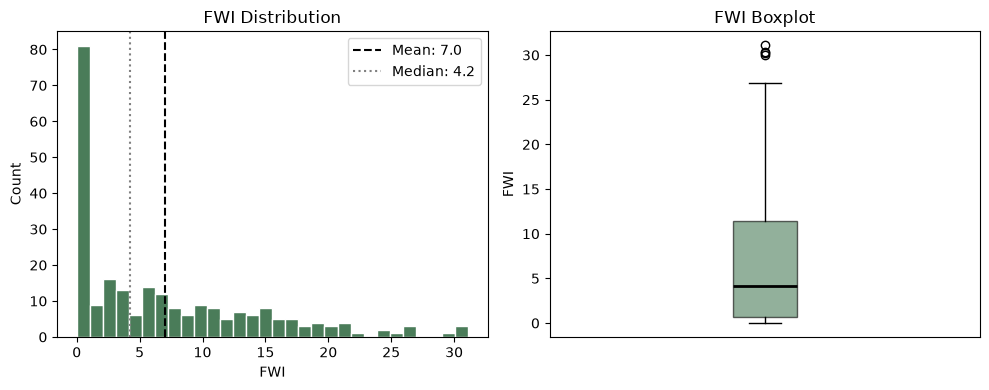

In [80]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['FWI'], bins=30, color='#4a7c59', edgecolor='white')
plt.axvline(df['FWI'].mean(),   color='black', linestyle='--', label=f"Mean: {df['FWI'].mean():.1f}")
plt.axvline(df['FWI'].median(), color='grey',  linestyle=':',  label=f"Median: {df['FWI'].median():.1f}")
plt.title('FWI Distribution')
plt.xlabel('FWI')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df['FWI'], patch_artist=True,
            boxprops=dict(facecolor='#4a7c59', alpha=0.6),
            medianprops=dict(color='black', linewidth=2))
plt.title('FWI Boxplot')
plt.ylabel('FWI')
plt.xticks([])

plt.tight_layout()
plt.show()

### 5.2 Feature Distribution

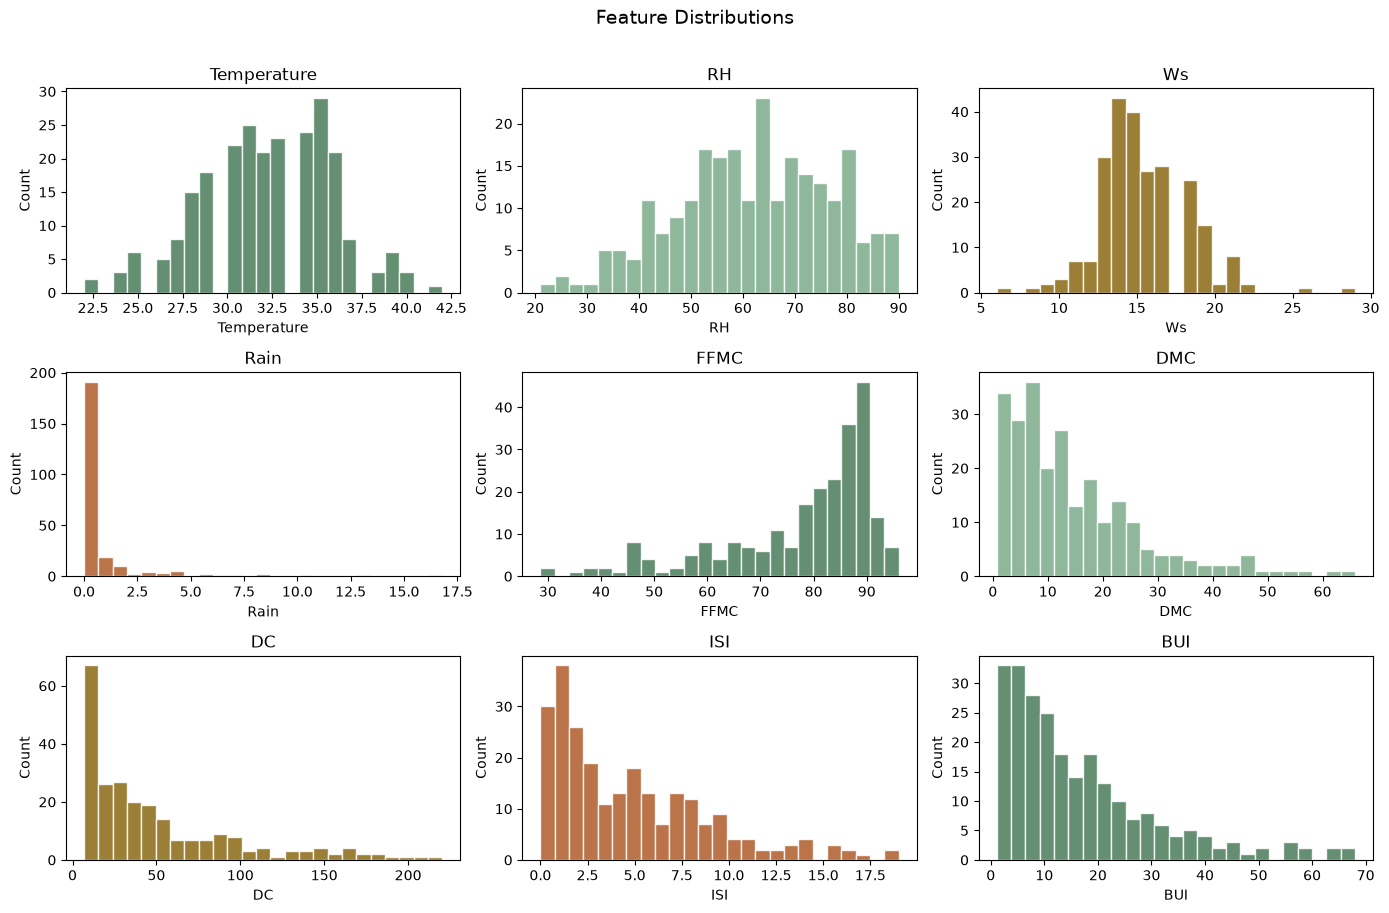

In [81]:
features = ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI']
colors   = ['#4a7c59', '#7aab8a', '#8b6914', '#b05c2a', '#4a7c59', '#7aab8a', '#8b6914', '#b05c2a', '#4a7c59']

plt.figure(figsize=(14, 9))

for i, (col, color) in enumerate(zip(features, colors)):
    plt.subplot(3, 3, i + 1)
    plt.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Monthly fire analysis

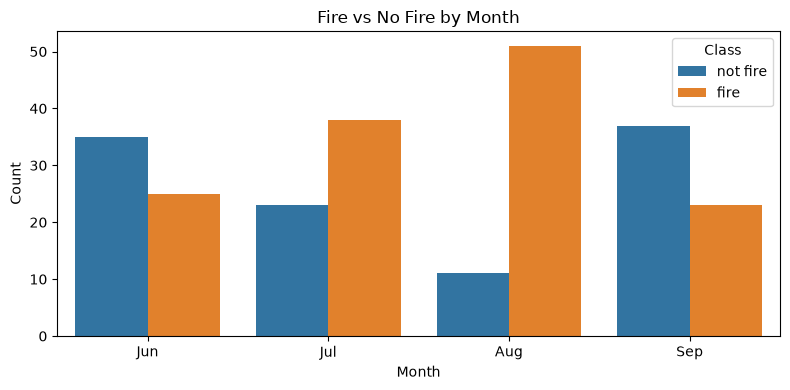

In [82]:
month_map = {6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep'}
df['month_name'] = df['month'].map(month_map)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='month_name', hue='Classes',
            order=['Jun', 'Jul', 'Aug', 'Sep'],
            )
plt.title('Fire vs No Fire by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

### 5.4 FWI vs Other features

In [83]:
features

['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI']

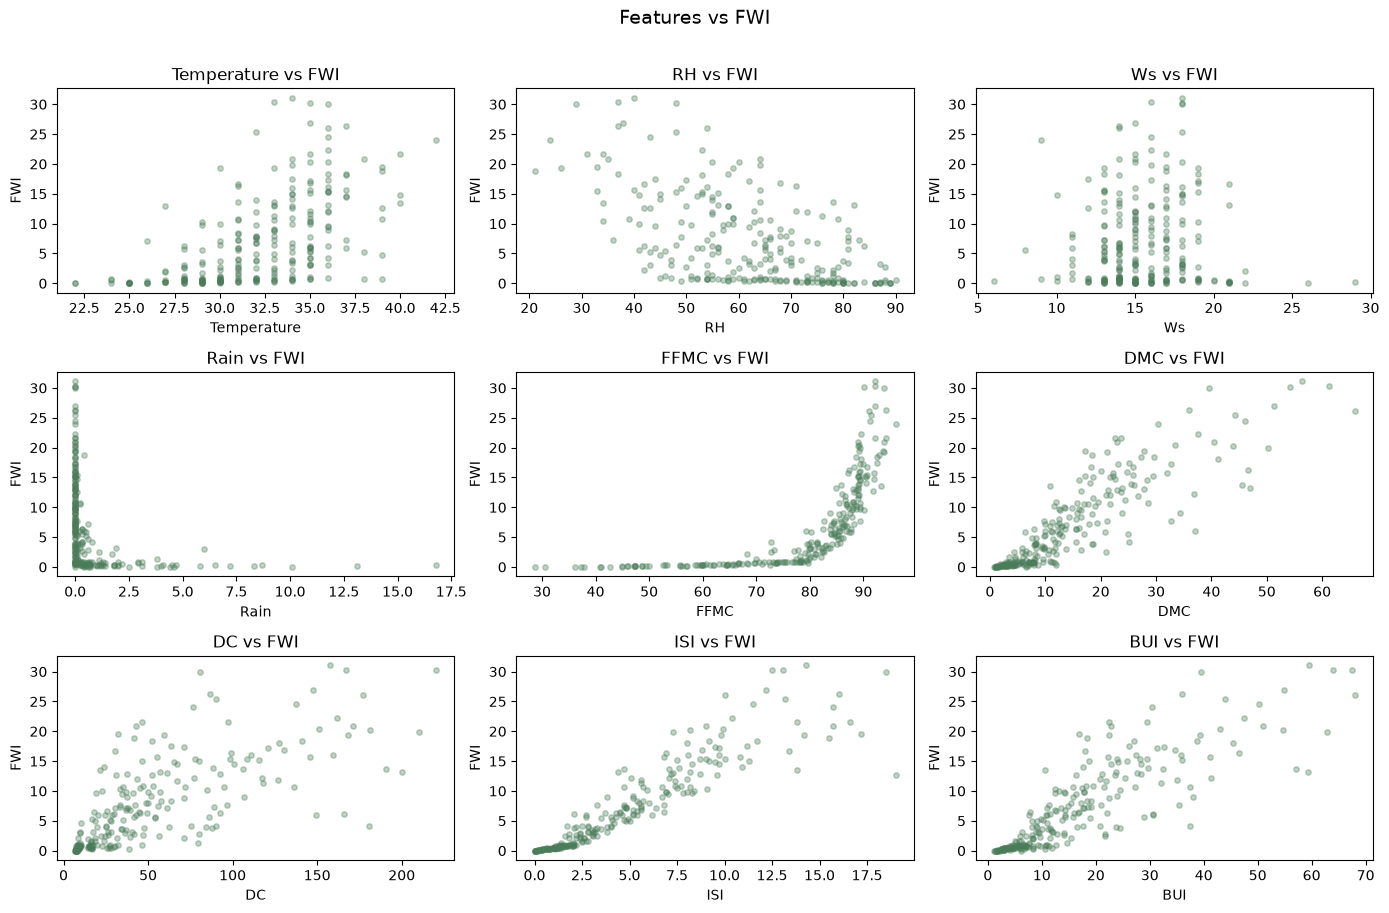

In [84]:
plt.figure(figsize=(14, 9))

for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    plt.scatter(df[col], df['FWI'], alpha=0.35, color='#4a7c59', s=15)
    plt.title(f'{col} vs FWI')
    plt.xlabel(col)
    plt.ylabel('FWI')

plt.suptitle('Features vs FWI', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.5 Correlation Heatmap

In [85]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,month_name
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,Jun
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,Jun
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,Jun
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,Jun
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,Jun


In [86]:
corr_cols = features + ['FWI']
corr = df[corr_cols].corr().round(2)
corr

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
Temperature,1.00,-0.65,-0.28,-0.33,0.68,0.49,0.38,0.60,0.46,0.57
RH,-0.65,1.00,0.24,0.22,-0.64,-0.41,-0.23,-0.69,-0.35,-0.58
Ws,-0.28,0.24,1.00,0.17,-0.17,-0.00,0.08,0.01,0.03,0.03
Rain,-0.33,0.22,0.17,1.00,-0.54,-0.29,-0.30,-0.35,-0.30,-0.32
FFMC,0.68,-0.64,-0.17,-0.54,1.00,0.60,0.51,0.74,0.59,0.69
DMC,0.49,-0.41,-0.00,-0.29,0.60,1.00,0.88,0.68,0.98,0.88
DC,0.38,-0.23,0.08,-0.30,0.51,0.88,1.00,0.51,0.94,0.74
ISI,0.60,-0.69,0.01,-0.35,0.74,0.68,0.51,1.00,0.64,0.92
BUI,0.46,-0.35,0.03,-0.30,0.59,0.98,0.94,0.64,1.00,0.86
FWI,0.57,-0.58,0.03,-0.32,0.69,0.88,0.74,0.92,0.86,1.00


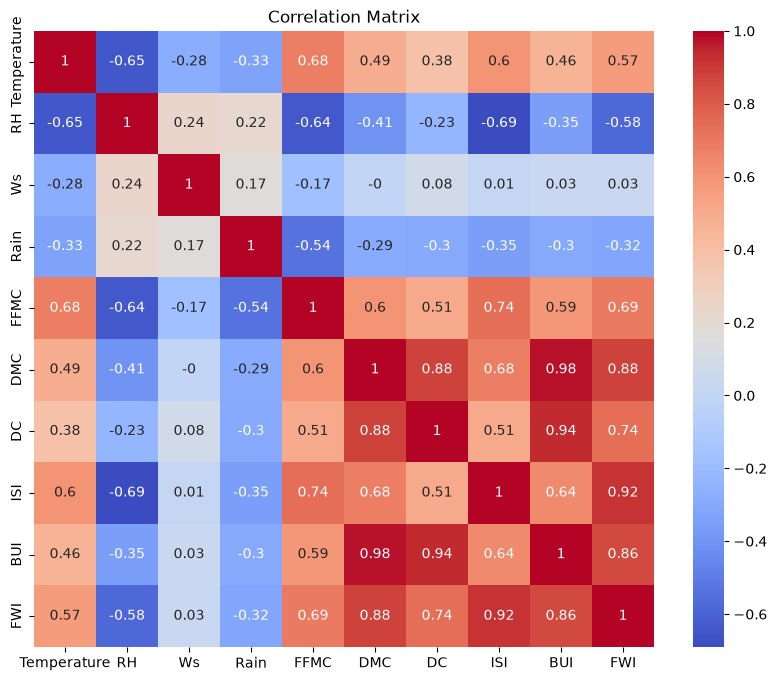

In [87]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 6. Feature Selection — Remove Highly Correlated Features

In [88]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

X = df[features]
corr_features = correlation(X, threshold=0.85)
print(f'Features to drop (corr > 0.85): {corr_features}')

Features to drop (corr > 0.85): {'DC', 'BUI'}


In [89]:
# Drop highly correlated features
X_clean = X.drop(columns=corr_features)
print(f'Features remaining: {list(X_clean.columns)}')

Features remaining: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI']


In [91]:
# Save the cleaned feature set + target
df_model = X_clean.copy()
df_model['FWI'] = df['FWI'].values

df_model.to_csv('datasets/algerian_forest_fire_cleaned.csv', index=False)
print(f'Saved algerian_forest_fire_cleaned.csv with shape: {df_model.shape}')
print(f'Columns: {list(df_model.columns)}')
df_model.head()

Saved algerian_forest_fire_cleaned.csv with shape: (243, 8)
Columns: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'FWI']


,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,FWI
0,29,57,18,0.0,65.7,3.4,1.3,0.5
1,29,61,13,1.3,64.4,4.1,1.0,0.4
2,26,82,22,13.1,47.1,2.5,0.3,0.1
3,25,89,13,2.5,28.6,1.3,0.0,0.0
4,27,77,16,0.0,64.8,3.0,1.2,0.5
